# Baseline e Estratégia Algorítmica

**Objetivo:** comparar uma regra fixa (baseline) com um algoritmo adaptativo de multi-armed bandit na tarefa de decidir, para cada cliente elegível, qual oferta apresentar e qual métrica de conversão do algoritmo adaptativo superando o baseline.

## Metodologia

Foi construído um **ambiente de simulação** a partir de:

- `offer_catalog.json`: fornece os braços (ofertas), suas taxas base de
  conversão e os multiplicadores por segmento.
- `bank_marketing_processed.parquet`: dados originais que fornecem o fluxo de clientes.

Para cada par (cliente, braço) simulamos se haveria conversão, usando a probabilidade
implícita no catálogo e **números aleatórios comuns** (mesma semente de ruído para todas as
estratégias).

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 42
N_CLIENTS = 20_000  # tamanho do horizonte simulado

CATALOG_PATH = "../data/synthetic_enrichment/offer_catalog.json"
DADOS_PATH = "../data/processed/bank_marketing_processed.parquet"

with open(CATALOG_PATH, encoding="utf-8") as f:
    catalog = json.load(f)

ARMS = {a["arm_id"]: a for a in catalog["arms"]}
ARM_IDS = list(ARMS.keys())
ARM_NAMES = {aid: a["name"] for aid, a in ARMS.items()}
BASE_RATE = {aid: a["base_conversion_rate"] for aid, a in ARMS.items()}
SEG_MULT = {aid: a["segment_multipliers"] for aid, a in ARMS.items()}

print(f"Braços carregados do catálogo: {len(ARM_IDS)}")
for aid in ARM_IDS:
    print(f"  {aid:15s} base_conversion_rate={BASE_RATE[aid]:.3f}  -  {ARM_NAMES[aid]}")

Braços carregados do catálogo: 9
  arm_001         base_conversion_rate=0.110  -  CDB 12 meses
  arm_002         base_conversion_rate=0.130  -  Poupança digital
  arm_003         base_conversion_rate=0.080  -  Previdência privada (PGBL)
  arm_004         base_conversion_rate=0.140  -  LCI / LCA 90 dias
  arm_005         base_conversion_rate=0.150  -  CDB liquidez diária
  arm_006         base_conversion_rate=0.060  -  Oferta de reengajamento
  arm_007         base_conversion_rate=0.090  -  CDB 24 meses (premium)
  arm_008         base_conversion_rate=0.160  -  Poupança estudantil
  arm_control     base_conversion_rate=0.040  -  Nenhuma ação


# 1. Derivação dos segmentos

In [2]:
MONTHS_HIGH = ["mar", "sep", "oct", "dec"]

def derive_segments(row: pd.Series) -> list[str]:
    segs = []
    if row["poutcome"] == "success":
        segs.append("previous_converter")
    if row["month"] in MONTHS_HIGH:
        segs.append("high_season")
    if row["job"] == "student" and row["contact"] == "cellular":
        segs.append("student_digital")
    if row["job"] == "student":
        segs.append("student_saver")
    if row["job"] == "retired":
        segs.append("retired")
    if row["education"] == "university.degree":
        segs.append("university_educated")
    if row["contact"] == "cellular":
        segs.append("digital_channel")
    if row["housing"] == "no" and row["loan"] == "no" and row.get("default", "no") == "no":
        segs.append("debt_free")
    if row["had_previous_contact"] == 0 and row["contacted_before"] == 0:
        segs.append("low_engagement")
    return segs

def expected_reward(arm_id: str, segments: list[str]) -> float:
    base = BASE_RATE[arm_id]
    mult = 1.0
    for seg in segments:
        if seg in SEG_MULT[arm_id]:
            mult *= SEG_MULT[arm_id][seg]
    return min(base * mult, 0.95)

# 2. Fluxo de Clientes e Matriz de Recompensa Contrafactual

Para cada cliente, calcula-se a probabilidade de conversão **para todos os braços** segundo o modelo de recompensa do catálogo. Isso gera uma matriz `N_CLIENTS × N_ARMS` de probabilidades, e a partir dela uma matriz de desfechos simulados (0/1) usando como uma única fonte de aleatoriedade o **common random numbers**

In [3]:
df = pd.read_parquet(DADOS_PATH, engine='pyarrow')
df = df.sample(n=N_CLIENTS, random_state=RANDOM_SEED).reset_index(drop=True)
print(f"Clientes amostrados: {df.shape}")

segments_list = [derive_segments(row) for _, row in df.iterrows()]

n_arms = len(ARM_IDS)
prob_matrix = np.zeros((N_CLIENTS, n_arms))
for j, aid in enumerate(ARM_IDS):
    for i, segs in enumerate(segments_list):
        prob_matrix[i, j] = expected_reward(aid, segs)

# common random numbers
rng_outcomes = np.random.RandomState(2026)
noise = rng_outcomes.random_sample((N_CLIENTS, n_arms))
outcome_matrix = (noise < prob_matrix).astype(int)

arm_idx = {aid: j for j, aid in enumerate(ARM_IDS)}
print("Matriz de desfechos simulados:", outcome_matrix.shape)

Clientes amostrados: (20000, 20)
Matriz de desfechos simulados: (20000, 9)


# 4. Baseline

Foi avaliado dois *baselines*:

- **Baseline fixo:** sempre oferecer o braço com a maior `base_conversion_rate` listada no catálogo — é a decisão que um time de marketing tomaria olhando só a ficha técnica de cada oferta, sem cruzar com o perfil de cada cliente.
- **Baseline aleatório:** escolha uniforme entre os braços (o que acontece sem nenhuma estratégia).

In [4]:
baseline_arm = max(BASE_RATE, key=BASE_RATE.get)
print(f"Baseline fixo escolhido: {baseline_arm} ({ARM_NAMES[baseline_arm]}), "
      f"base_conversion_rate={BASE_RATE[baseline_arm]:.3f}")

j_baseline = arm_idx[baseline_arm]
baseline_rewards = outcome_matrix[:, j_baseline]
baseline_cum_rate = np.cumsum(baseline_rewards) / (np.arange(N_CLIENTS) + 1)

rng_policy = np.random.RandomState(123)
random_choices = rng_policy.randint(0, n_arms, size=N_CLIENTS)
random_rewards = outcome_matrix[np.arange(N_CLIENTS), random_choices]
random_cum_rate = np.cumsum(random_rewards) / (np.arange(N_CLIENTS) + 1)

print(f"\nConversão final - baseline fixo:   {baseline_cum_rate[-1]:.4f}")
print(f"Conversão final - baseline random: {random_cum_rate[-1]:.4f}")

Baseline fixo escolhido: arm_008 (Poupança estudantil), base_conversion_rate=0.160

Conversão final - baseline fixo:   0.3317
Conversão final - baseline random: 0.1787


# 5. Thompson Sampling

Para cada braço mantemos uma distribuição Beta(α, β) representando a crença sobre sua taxa de conversão, começando neutra em Beta(1, 1). A cada cliente:

1. Sorteamos um valor de cada Beta(α, β) dos braços elegíveis.
2. Escolhemos o braço com o maior valor sorteado.
3. Observamos a recompensa (conversão simulada) e atualizamos: `α += r`, `β += (1 - r)`.

In [5]:
alpha = np.ones(n_arms)
beta = np.ones(n_arms)
ts_rng = np.random.RandomState(7)

ts_rewards = np.zeros(N_CLIENTS)
ts_choices = np.zeros(N_CLIENTS, dtype=int)

for i in range(N_CLIENTS):
    samples = ts_rng.beta(alpha, beta)
    a = int(np.argmax(samples))
    r = outcome_matrix[i, a]
    alpha[a] += r
    beta[a] += (1 - r)
    ts_rewards[i] = r
    ts_choices[i] = a

ts_cum_rate = np.cumsum(ts_rewards) / (np.arange(N_CLIENTS) + 1)
print(f"Conversão final - Thompson Sampling: {ts_cum_rate[-1]:.4f}")

uplift = 100 * (ts_cum_rate[-1] / baseline_cum_rate[-1] - 1)
print(f"Uplift do Thompson Sampling sobre o baseline fixo: {uplift:.1f}%")

Conversão final - Thompson Sampling: 0.4122
Uplift do Thompson Sampling sobre o baseline fixo: 24.3%


# 6. UCB1 (Upper Confidence Bound)

UCB1 escolhe, a cada rodada, o braço que maximiza:

`média observada do braço + sqrt(2 * ln(t) / n_vezes_escolhido)`

O UCB1 é **determinístico** dado o histórico (diferente do Thompson Sampling, que sorteia). Cada braço é testado uma vez no início antes da fórmula entrar em vigor.

In [6]:
ucb_counts = np.zeros(n_arms)
ucb_sums = np.zeros(n_arms)
ucb_rewards = np.zeros(N_CLIENTS)
ucb_choices = np.zeros(N_CLIENTS, dtype=int)

for i in range(N_CLIENTS):
    if i < n_arms:
        a = i  # warm-up: testa cada braço uma vez
    else:
        means = ucb_sums / ucb_counts
        bonus = np.sqrt(2 * np.log(i + 1) / ucb_counts)
        a = int(np.argmax(means + bonus))
    r = outcome_matrix[i, a]
    ucb_counts[a] += 1
    ucb_sums[a] += r
    ucb_rewards[i] = r
    ucb_choices[i] = a

ucb_cum_rate = np.cumsum(ucb_rewards) / (np.arange(N_CLIENTS) + 1)
print(f"Conversão final - UCB1: {ucb_cum_rate[-1]:.4f}")

Conversão final - UCB1: 0.3922


# 7. Epsilon-Greedy

A cada rodada, com probabilidade `epsilon` escolhe um braço aleatório (exploração), e com probabilidade `1 - epsilon` escolhe o braço com maior média observada até agora (explotação). Diferente do Thompson Sampling e do UCB1, a taxa de exploração aqui é **constante e não decai com a evidência acumulada**. Foi usado o `epsilon = 0.1` (10% de exploração).

In [7]:
EPSILON = 0.10
eg_rng = np.random.RandomState(99)

eg_counts = np.zeros(n_arms)
eg_sums = np.zeros(n_arms)
eg_rewards = np.zeros(N_CLIENTS)
eg_choices = np.zeros(N_CLIENTS, dtype=int)

for i in range(N_CLIENTS):
    if eg_counts.min() == 0:
        a = int(np.argmin(eg_counts))  # warm-up, igual ao UCB1
    elif eg_rng.random() < EPSILON:
        a = eg_rng.randint(0, n_arms)
    else:
        a = int(np.argmax(eg_sums / eg_counts))
    r = outcome_matrix[i, a]
    eg_counts[a] += 1
    eg_sums[a] += r
    eg_rewards[i] = r
    eg_choices[i] = a

eg_cum_rate = np.cumsum(eg_rewards) / (np.arange(N_CLIENTS) + 1)
print(f"Conversão final - Epsilon-Greedy (eps={EPSILON}): {eg_cum_rate[-1]:.4f}")

Conversão final - Epsilon-Greedy (eps=0.1): 0.3910


# 8. Comparação

In [8]:
summary = pd.DataFrame({
    "estrategia": [
        "Baseline fixo (maior base_rate)", "Baseline aleatório",
        "Thompson Sampling", "UCB1", "Epsilon-Greedy (0.10)",
    ],
    "conversao_final": [
        baseline_cum_rate[-1], random_cum_rate[-1],
        ts_cum_rate[-1], ucb_cum_rate[-1], eg_cum_rate[-1],
    ],
})
summary["uplift_vs_baseline_fixo_%"] = 100 * (summary["conversao_final"] / baseline_cum_rate[-1] - 1)
summary.sort_values("conversao_final", ascending=False).reset_index(drop=True)

,estrategia,conversao_final,uplift_vs_baseline_fixo_%
0,Thompson Sampling,0.41220,24.287653
1,UCB1,0.39220,18.257199
2,Epsilon-Greedy (0.10),0.39100,17.895372
3,Baseline fixo (maior base_rate),0.33165,0.000000
4,Baseline aleatório,0.17865,-46.132972


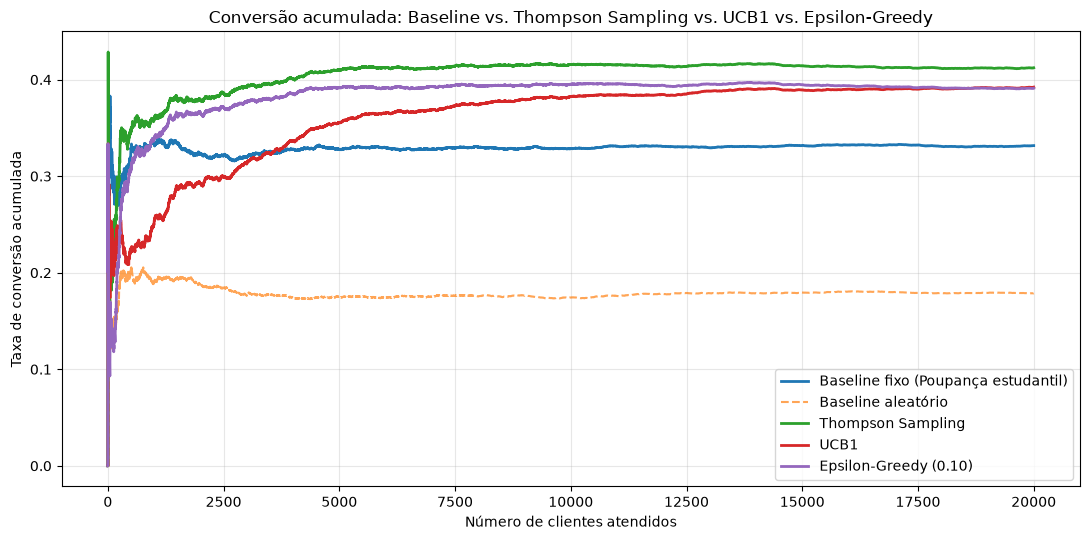

In [9]:
fig, ax = plt.subplots(figsize=(11, 5.5))
rounds = np.arange(1, N_CLIENTS + 1)
ax.plot(rounds, baseline_cum_rate, label=f"Baseline fixo ({ARM_NAMES[baseline_arm]})", linewidth=2)
ax.plot(rounds, random_cum_rate, label="Baseline aleatório", linewidth=1.5, linestyle="--", alpha=0.7)
ax.plot(rounds, ts_cum_rate, label="Thompson Sampling", linewidth=2)
ax.plot(rounds, ucb_cum_rate, label="UCB1", linewidth=2)
ax.plot(rounds, eg_cum_rate, label="Epsilon-Greedy (0.10)", linewidth=2)
ax.set_xlabel("Número de clientes atendidos")
ax.set_ylabel("Taxa de conversão acumulada")
ax.set_title("Conversão acumulada: Baseline vs. Thompson Sampling vs. UCB1 vs. Epsilon-Greedy")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

- **Thompson Sampling** e **UCB1** ficam à frente do **Epsilon-Greedy**, que por sua vez fica à frente do baseline fixo, que já supera confortavelmente
o piso aleatório.

# 9. Convergência: para qual braço cada algoritmo migra?

In [10]:
def convergence_table(choices, label):
    second_half = choices[N_CLIENTS // 2:]
    vals, counts = np.unique(second_half, return_counts=True)
    df_c = pd.DataFrame({
        "algoritmo": label,
        "arm_id": [ARM_IDS[v] for v in vals],
        "nome": [ARM_NAMES[ARM_IDS[v]] for v in vals],
        "pct_escolhas_2a_metade": [100 * c / len(second_half) for c in counts],
    })
    return df_c.sort_values("pct_escolhas_2a_metade", ascending=False).head(3)

conv_all = pd.concat([
    convergence_table(ts_choices, "Thompson Sampling"),
    convergence_table(ucb_choices, "UCB1"),
    convergence_table(eg_choices, "Epsilon-Greedy"),
]).reset_index(drop=True)
conv_all

,algoritmo,arm_id,nome,pct_escolhas_2a_metade
0,Thompson Sampling,arm_005,CDB liquidez diária,99.08
1,Thompson Sampling,arm_008,Poupança estudantil,0.80
2,Thompson Sampling,arm_006,Oferta de reengajamento,0.04
3,UCB1,arm_005,CDB liquidez diária,92.54
4,UCB1,arm_008,Poupança estudantil,4.42
5,UCB1,arm_004,LCI / LCA 90 dias,0.72
6,Epsilon-Greedy,arm_005,CDB liquidez diária,90.72
7,Epsilon-Greedy,arm_control,Nenhuma ação,1.26
8,Epsilon-Greedy,arm_003,Previdência privada (PGBL),1.26



- Os três algoritmos adaptativos convergem para o mesmo braço vencedor (arm_005), confirmando que a política populacional ótima é consistente entre eles.

## 10. Thompson Sampling contextual — comparando antes de decidir a política final

Antes de fechar a escolha da política de produção, vale testar uma variante do Thompson
Sampling que também usa o segmento do cliente na decisão: em vez de manter um único
posterior Beta por braço (seção 5), mantemos um posterior Beta por **(segmento, braço)**.

A regra de segmento é a mesma de `context_segment()` em produção: `previous_converter` > `student_digital` > `retired` >
`low_engagement` > `digital_channel` > `general`, primeira regra que casar vence (diferente
dos rótulos multi-tag de `derive_segments()` na seção 1, que serviram só para construir a
matriz de recompensa esperada).

In [11]:
SEGMENTS = (
    "previous_converter", "student_digital", "retired",
    "low_engagement", "digital_channel", "general",
)

def context_segment(row: pd.Series) -> str:
    """Mesma regra de `src/datathon/bandits/contextual_thompson.py::context_segment`."""
    if row["poutcome"] == "success":
        return "previous_converter"
    if row["job"] == "student" and row["contact"] == "cellular":
        return "student_digital"
    if row["job"] == "retired":
        return "retired"
    if row["previous"] == 0 and row["contacted_before"] == 0:
        return "low_engagement"
    if row["contact"] == "cellular":
        return "digital_channel"
    return "general"

client_segments = [context_segment(row) for _, row in df.iterrows()]
print(pd.Series(client_segments).value_counts())

ctx_alpha = {seg: np.ones(n_arms) for seg in SEGMENTS}
ctx_beta = {seg: np.ones(n_arms) for seg in SEGMENTS}
ctx_rng = np.random.RandomState(7)  # mesma seed do Thompson global (seção 5), para comparação justa
ctx_rewards = np.zeros(N_CLIENTS)
ctx_choices = np.zeros(N_CLIENTS, dtype=int)

for i in range(N_CLIENTS):
    seg = client_segments[i]
    samples = ctx_rng.beta(ctx_alpha[seg], ctx_beta[seg])
    a = int(np.argmax(samples))
    r = outcome_matrix[i, a]
    ctx_alpha[seg][a] += r
    ctx_beta[seg][a] += (1 - r)
    ctx_rewards[i] = r
    ctx_choices[i] = a

ctx_cum_rate = np.cumsum(ctx_rewards) / (np.arange(N_CLIENTS) + 1)
print(f"\nConversão final - Thompson Sampling contextual: {ctx_cum_rate[-1]:.4f}")

uplift_ctx = 100 * (ctx_cum_rate[-1] / baseline_cum_rate[-1] - 1)
gain_vs_global = 100 * (ctx_cum_rate[-1] / ts_cum_rate[-1] - 1)
print(f"Uplift sobre o baseline fixo: {uplift_ctx:.1f}%")
print(f"Ganho sobre o Thompson global (seção 5): {gain_vs_global:+.2f}%")

low_engagement        16348
digital_channel        1778
retired                 743
previous_converter      691
student_digital         293
general                 147
Name: count, dtype: int64

Conversão final - Thompson Sampling contextual: 0.4123
Uplift sobre o baseline fixo: 24.3%
Ganho sobre o Thompson global (seção 5): +0.04%


In [12]:
def contextual_convergence_table():
    seg_arr = np.array(client_segments)
    second_half = slice(N_CLIENTS // 2, N_CLIENTS)
    rows = []
    for seg in SEGMENTS:
        mask = seg_arr[second_half] == seg
        if mask.sum() == 0:
            continue
        chosen = ctx_choices[second_half][mask]
        vals, counts = np.unique(chosen, return_counts=True)
        top = vals[np.argmax(counts)]
        rows.append({
            "segmento": seg,
            "n_clientes_2a_metade": int(mask.sum()),
            "braço mais escolhido": ARM_IDS[top],
            "nome": ARM_NAMES[ARM_IDS[top]],
            "concentração": f"{100 * counts.max() / mask.sum():.1f}%",
        })
    return pd.DataFrame(rows)

contextual_convergence_table()

,segmento,n_clientes_2a_metade,braço mais escolhido,nome,concentração
0,previous_converter,355,arm_005,CDB liquidez diária,52.1%
1,student_digital,141,arm_008,Poupança estudantil,83.7%
2,retired,355,arm_005,CDB liquidez diária,99.4%
3,low_engagement,8166,arm_005,CDB liquidez diária,99.8%
4,digital_channel,907,arm_004,LCI / LCA 90 dias,86.9%
5,general,76,arm_008,Poupança estudantil,26.3%


**O que essa comparação mostra:**

- Na segunda metade do horizonte, cada segmento converge para um braço próprio
  (`student_digital` e `general` puxam para Poupança estudantil, `digital_channel` para
  LCI/LCA 90 dias, os demais para CDB liquidez diária) — é a personalização que o Thompson
  global, com um único posterior para toda a base, não consegue expressar.
- Em conversão agregada, porém, o ganho sobre o Thompson global desta seção é pequeno
  (em torno de 0,04% relativo, ~0,4123 vs. ~0,4122): a amostra aqui é dominada por
  `low_engagement` (~82% dos clientes), e nesse segmento o braço vencedor já coincide com o
  braço vencedor global — segmentar não muda muito a média quando um segmento domina a base.
  O ganho de personalização aparece nos segmentos minoritários, não no agregado.
- O padrão é consistente com a avaliação oficial da Etapa 4 (`uv run datathon-evaluate`, ver
  [`reports/etapa4_avaliacao.md`](../reports/etapa4_avaliacao.md) e o README): lá o Thompson
  contextual (0,4139) também supera o global (0,4128) por uma margem pequena
  (+24,8% vs. +24,5% de uplift), rodando os 20.000 clientes completos com o `random.Random`
  das classes de produção — não o `numpy.random` usado aqui.

Com o global, o UCB1 e o Epsilon-Greedy já comparados nas seções 8 e 9, e o contextual
comparado aqui, a próxima seção fecha a escolha da política final de produção.

## 11. Escolha Final

Foi escolhido o **Thompson Sampling contextual** (seção 10) como política final de produção,
em vez do Thompson Sampling global (seção 5), pelos seguintes motivos:

- **Não precisa de hiperparâmetro de exploração para ajustar manualmente.** O Epsilon-Greedy
  exige escolher e justificar um `epsilon` fixo (aqui usamos 0.10 por convenção); errar esse
  valor desperdiça tráfego indefinidamente ou explora de menos. O Thompson Sampling e o UCB1
  não têm esse parâmetro livre.
- **Exploração que decai sozinha com a evidência**, ao contrário do Epsilon-Greedy, cuja taxa
  de exploração continua constante mesmo depois de milhares de decisões.
- **Personalização auditável por segmento.** A comparação da seção 10 mostra que, mesmo o
  ganho agregado sobre o Thompson global sendo pequeno (a base é dominada por
  `low_engagement`), cada segmento converge para um braço próprio — ganho que o Thompson
  global não consegue expressar. O contextual usa o mesmo segmento que `GET /segment` expõe
  em produção, com o mesmo prior Beta(1, 1) só particionado por segmento — sem custo extra de
  complexidade.

In [13]:
import os

os.makedirs("../data/processed", exist_ok=True)

policy_state = {
    "algorithm": "thompson_sampling_contextual",
    "arm_ids": ARM_IDS,
    "segments": list(SEGMENTS),
    "alpha": {seg: ctx_alpha[seg].tolist() for seg in SEGMENTS},
    "beta": {seg: ctx_beta[seg].tolist() for seg in SEGMENTS},
    "trained_on_n_clients": int(N_CLIENTS),
    "random_seed": RANDOM_SEED,
}

with open("../data/processed/thompson_policy_state.json", "w", encoding="utf-8") as f:
    json.dump(policy_state, f, ensure_ascii=False, indent=2)

print("Estado da política (contextual) salvo em data/processed/thompson_policy_state.json")
policy_state

Estado da política (contextual) salvo em data/processed/thompson_policy_state.json


{'algorithm': 'thompson_sampling_contextual',
 'arm_ids': ['arm_001',
  'arm_002',
  'arm_003',
  'arm_004',
  'arm_005',
  'arm_006',
  'arm_007',
  'arm_008',
  'arm_control'],
 'segments': ['previous_converter',
  'student_digital',
  'retired',
  'low_engagement',
  'digital_channel',
  'general'],
 'alpha': {'previous_converter': [8.0,
   7.0,
   3.0,
   26.0,
   192.0,
   1.0,
   162.0,
   29.0,
   1.0],
  'student_digital': [1.0, 4.0, 1.0, 1.0, 93.0, 1.0, 1.0, 168.0, 1.0],
  'retired': [2.0, 3.0, 1.0, 2.0, 611.0, 1.0, 1.0, 1.0, 1.0],
  'low_engagement': [2.0, 8.0, 3.0, 7.0, 6415.0, 2.0, 1.0, 13.0, 1.0],
  'digital_channel': [6.0, 10.0, 16.0, 411.0, 37.0, 4.0, 2.0, 7.0, 1.0],
  'general': [2.0, 3.0, 3.0, 3.0, 5.0, 2.0, 3.0, 9.0, 2.0]},
 'beta': {'previous_converter': [10.0,
   11.0,
   8.0,
   17.0,
   107.0,
   5.0,
   93.0,
   23.0,
   6.0],
  'student_digital': [2.0, 3.0, 3.0, 3.0, 11.0, 3.0, 3.0, 10.0, 2.0],
  'retired': [5.0, 6.0, 4.0, 5.0, 103.0, 4.0, 3.0, 4.0, 4.0],
  'low